# March 30 — Improved Stellar Age Pipeline

Improvements over `march23__week.ipynb`:
- **Av bound tightened** (0 → 0.15 for <100 pc) — stops extinction absorbing model offsets
- **F99 extinction law** (Fitzpatrick 1999) replaces CCM89
- **Flat age prior** in log-age replaces the Gaussian biased toward 9.5 (3 Gyr)
- **[Fe/H] as a free parameter** with Gaussian prior from catalog (now 4 MCMC params)
- **Kroupa IMF mass prior** replaces the ad-hoc Gaussian + low-mass penalty hack
- **logg constraint** added to likelihood when `st_logg` is in the catalog
- **Real Gaia errors** from `e_gaiamag` replace hardcoded 0.01
- **Parallax uncertainty propagated** into absolute magnitude errors
- **Smart walker initialization** from Teff-to-mass estimate (reduces burn-in)
- **MCMC convergence diagnostics** — autocorrelation time + acceptance fraction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
from astroquery.gaia import Gaia
from scipy.interpolate import RegularGridInterpolator
from isochrones.mist import MIST_Isochrone
import emcee
import astropy.units as u
from dust_extinction.parameter_averages import F99  # Fitzpatrick 1999, replaces CCM89

mist = MIST_Isochrone()

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


PyMultiNest not imported.  MultiNest fits will not work.


## 1. Helper Functions

Updated Gaia query returns both `parallax` and `parallax_error` so we can
propagate the distance uncertainty into every absolute magnitude.

In [2]:
def get_distance_info(ra, dec, radius=2/3600):
    """Query Gaia DR3 near (ra, dec). Returns (distance_pc, distance_err_pc)."""
    query = f"""
    SELECT TOP 1 parallax, parallax_error
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    AND parallax > 0
    """
    job = Gaia.launch_job(query)
    result = job.get_results()
    if len(result) == 0:
        return np.nan, np.nan
    plx     = float(result['parallax'][0])
    plx_err = float(result['parallax_error'][0])
    if plx <= 0:
        return np.nan, np.nan
    dist_pc     = 1000.0 / plx
    # error propagation: sigma_d = sigma_pi / pi^2 * 1000
    dist_err_pc = 1000.0 * plx_err / plx**2
    return dist_pc, dist_err_pc


def apparent_to_absolute(m_app, distance_pc):
    """Standard distance modulus."""
    return m_app - 5.0 * np.log10(distance_pc / 10.0)


def add_dist_err(phot_err, dist_pc, dist_err_pc):
    """Add parallax uncertainty in quadrature with the photometric error.

    mu = 5 log10(d/10)  =>  sigma_mu = 5 * sigma_d / (d * ln10)
    Same systematic shift applies to every band.
    """
    sigma_mu = 5.0 * dist_err_pc / (dist_pc * np.log(10))
    return np.sqrt(phot_err**2 + sigma_mu**2)

## 2. Load and Merge Data

Now keeps `st_logg` and uses real Gaia errors (`e_gaiamag`).

In [3]:
df1 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Target_List.csv")
df2 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv")

df1 = df1.drop_duplicates(subset="hostname")
df2 = df2.drop_duplicates(subset="hostname")

merged = pd.merge(df1, df2, on="hostname", how="inner")
merged["ra"]  = merged["ra_x"]
merged["dec"] = merged["dec_x"]
merged = merged.drop(columns=["ra_x", "ra_y", "dec_x", "dec_y", "pl_name_y"])

want_cols = [
    "hostname", "st_teff", "st_logg", "st_age", "st_met",
    "ra", "dec",
    "gaia_Gmag", "e_gaiamag",
    "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
    "e_Jmag", "e_Hmag", "e_Kmag",
]
merged = merged[[c for c in want_cols if c in merged.columns]]

merged = merged.dropna(subset=[
    "st_teff", "st_age", "st_met", "ra", "dec",
    "gaia_Gmag", "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
])

merged["e_gaiamag"] = merged["e_gaiamag"].fillna(0.01)
merged["e_Jmag"]    = merged["e_Jmag"].fillna(0.03)
merged["e_Hmag"]    = merged["e_Hmag"].fillna(0.03)
merged["e_Kmag"]    = merged["e_Kmag"].fillna(0.03)

print(f"Stars with complete photometry: {len(merged)}")

# --- query Gaia for parallax + error ---
merged_sample = merged.head(300).copy()

dist_results = merged_sample.apply(
    lambda row: get_distance_info(row["ra"], row["dec"]), axis=1
)
merged_sample["distance_pc"]     = [r[0] for r in dist_results]
merged_sample["distance_err_pc"] = [r[1] for r in dist_results]

merged_sample = merged_sample.dropna(subset=["distance_pc"])
merged_sample = merged_sample[merged_sample["distance_pc"] <= 100].copy()
merged_sample = merged_sample.reset_index(drop=True)

print(f"Stars within 100 pc: {len(merged_sample)}")
display(HTML(merged_sample.head(10).to_html()))

Stars with complete photometry: 2824
Stars within 100 pc: 61


,hostname,st_teff,st_logg,st_age,st_met,ra,dec,gaia_Gmag,e_gaiamag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,distance_pc,distance_err_pc
0,HIP 65 A,4590.0,4.611,4.10,0.18,0.185606,-54.830823,10.588468,0.000446,11.212916,9.835994,8.922,8.400,8.290,0.019,0.031,0.025,61.865322,0.035680
1,TOI-198,3650.0,4.750,5.30,-0.70,2.271509,-27.121745,10.915721,0.000655,11.910542,9.930160,8.655,8.143,7.856,0.024,0.026,0.021,23.776037,0.018320
2,Gliese 12,3296.0,5.210,7.00,-0.32,3.957914,13.557617,11.399355,0.001756,12.830511,10.227193,8.619,8.068,7.807,0.020,0.026,0.020,12.166368,0.004818
3,HD 1397,5521.0,3.823,4.51,0.29,4.447163,-66.358929,7.605658,0.000278,7.984488,7.055598,6.442,6.090,5.988,0.020,0.049,0.018,80.042045,0.108865
4,TOI-260,4026.0,4.450,15.90,-0.47,4.773018,-9.966150,9.316666,0.000458,10.124876,8.434608,7.376,6.710,6.549,0.020,0.031,0.021,20.211922,0.007260
5,TOI-178,4316.0,4.450,6.00,-0.23,7.302011,-30.454116,11.157550,0.000890,11.839834,10.360156,9.372,8.761,8.656,0.021,0.023,0.021,62.892960,0.122007
6,HD 3167,5261.0,4.530,7.80,0.04,8.740149,4.380721,8.772422,0.000265,9.178295,8.196435,7.548,7.203,7.066,0.032,0.038,0.020,47.312007,0.041852
7,TOI-1470,3709.0,4.770,1.30,0.00,10.089143,61.213387,12.542486,0.000285,13.669263,11.486450,10.154,9.514,9.283,0.024,0.032,0.020,51.739129,0.034937
8,TOI-244,3433.0,4.660,7.00,-0.39,10.569754,-36.717974,11.548954,0.001017,12.933047,10.387751,8.827,8.251,7.970,0.023,0.033,0.029,22.075149,0.013174
9,LHS 1140,3096.0,5.041,5.00,-0.15,11.248632,-15.274109,12.653936,0.000356,14.414495,11.383511,9.612,9.092,8.821,0.023,0.026,0.024,14.963621,0.010719


## 3. Build MIST Interpolation Grid

Now also interpolates `logg` so it can be used as a likelihood constraint.

In [4]:
age_grid  = np.linspace(6.0, 10.2, 60)
feh_grid  = np.linspace(-2.5,  0.5, 31)
mass_grid = np.linspace(0.1,  10.0, 200)

bands_interp = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'Teff', 'logg']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {b: np.full(shape, np.nan) for b in bands_interp}

print("Building MIST grid (this takes a few minutes)...")
for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values("initial_mass")
        for b in bands_interp:
            if b not in iso.columns:
                continue
            cubes[b][i, j, :] = np.interp(
                mass_grid, iso["initial_mass"], iso[b],
                left=np.nan, right=np.nan
            )

interpolators = {}
for b in bands_interp:
    interpolators[b] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[b],
        bounds_error=False,
        fill_value=np.nan
    )

print("Done. Interpolators:", list(interpolators.keys()))

# quick sanity check: solar twin should give G~4.8, logg~4.4, Teff~5778 K
test = [[9.66, 0.0, 1.0]]
print(f"Solar check  G={interpolators['G_mag'](test)[0]:.2f}  "
      f"logg={interpolators['logg'](test)[0]:.2f}  "
      f"Teff={interpolators['Teff'](test)[0]:.0f} K")

Building MIST grid (this takes a few minutes)...
Done. Interpolators: ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'Teff', 'logg']
Solar check  G=4.55  logg=4.42  Teff=5847 K


## 4. Model Definition

**Free parameters**: `(logage, mass, Av, feh)` — 4 parameters.

Changes from the previous version:

| What | Old | New |
|------|-----|-----|
| Extinction law | CCM89 | F99 (Fitzpatrick 1999) |
| Av upper bound | 0.30 | 0.15 (realistic for <100 pc) |
| Age prior | Gaussian N(9.5, 1.5) | Flat (data decides) |
| Mass prior | Gaussian N(1.0, 0.3) + penalty hack | Kroupa IMF |
| Metallicity | Fixed at catalog value | Free param with Gaussian prior |
| logg | Not used | Chi2 constraint if available |
| Gaia errors | Hardcoded 0.01 | From catalog e_gaiamag |
| Parallax error | Ignored | Propagated into magnitude errors |

In [5]:
# Fitzpatrick (1999) extinction law
ext_model = F99(Rv=3.1)

fit_bands = ["G", "BP", "RP", "J", "H", "K"]
band_map  = {"G": "G_mag", "BP": "BP_mag", "RP": "RP_mag",
             "J": "J_mag",  "H":  "H_mag",  "K":  "K_mag"}

# effective central wavelengths in Angstroms
band_wavelengths = {
    "G":  6231, "BP": 5323, "RP": 7725,
    "J":  12350, "H": 16620, "K": 21590,
}

# precompute A(lambda)/A(V) at each band — avoids repeating per call
ext_coeffs = {b: float(ext_model(band_wavelengths[b] * u.AA)) for b in fit_bands}
print("Extinction A(λ)/A(V):")
for b, c in ext_coeffs.items():
    print(f"  {b:3s}: {c:.4f}")


def chi2_model(params, star):
    logage, mass, Av, feh = params
    feh_c = np.clip(feh, feh_grid.min(), feh_grid.max())
    pt = [[logage, feh_c, mass]]

    # photometric chi2
    y    = np.array([star["photometry"][b] for b in fit_bands])
    yerr = np.array([star["phot_err"][b]   for b in fit_bands])

    model_mags = np.array([interpolators[band_map[b]](pt)[0] for b in fit_bands])
    if np.any(np.isnan(model_mags)):
        return 1e10

    # extinction: A(lambda) = ext_coeff * Av
    A_lambda       = np.array([ext_coeffs[b] * Av for b in fit_bands])
    model_mags_ext = model_mags + A_lambda

    chi2_phot = np.sum(((y - model_mags_ext) / yerr) ** 2)

    # Teff chi2 (100 K typical spectroscopic uncertainty)
    Teff_model = interpolators["Teff"](pt)[0]
    if np.isnan(Teff_model):
        return 1e10
    chi2_teff = ((star["Teff"] - Teff_model) / star["teff_err"]) ** 2

    # logg chi2 — only when catalog logg is available
    # logg tightly constrains mass and evolutionary state
    chi2_logg = 0.0
    if not np.isnan(star["logg"]):
        logg_model = interpolators["logg"](pt)[0]
        if not np.isnan(logg_model):
            chi2_logg = ((star["logg"] - logg_model) / 0.1) ** 2

    return chi2_phot + chi2_teff + chi2_logg


def log_prior(params, star):
    logage, mass, Av, feh = params

    # hard bounds
    if not (6.0  <= logage <= 10.2):             return -np.inf
    if not (0.1  <= mass   <= 2.5):              return -np.inf
    if not (0.0  <= Av     <= 0.15):             return -np.inf  # tighter for <100 pc
    if not (feh_grid.min() <= feh <= feh_grid.max()): return -np.inf

    # 1. flat age prior: no preference for old vs young stars
    log_prior_age = 0.0

    # 2. Kroupa (2001) IMF: alpha=1.3 below 0.5 Msun, alpha=2.3 above
    if mass < 0.5:
        log_prior_mass = -1.3 * np.log(mass)
    else:
        log_prior_mass = -2.3 * np.log(mass)

    # 3. distance-scaled Av prior
    # typical ISM: ~0.7 mag/kpc  =>  ~0.07 mag at 100 pc
    d          = star["distance_pc"]
    Av_expect  = 0.0007 * d
    Av_sigma   = 0.02 + 0.0005 * d
    log_prior_Av = -0.5 * ((Av - Av_expect) / Av_sigma) ** 2

    # 4. [Fe/H] Gaussian prior from spectroscopy (keeps us near catalog value)
    log_prior_feh = -0.5 * ((feh - star["feh"]) / star["feh_err"]) ** 2

    return log_prior_age + log_prior_mass + log_prior_Av + log_prior_feh


def log_probability(params, star):
    lp = log_prior(params, star)
    if not np.isfinite(lp):
        return -np.inf
    return lp - 0.5 * chi2_model(params, star)

Extinction A(λ)/A(V):
  G  : 0.8214
  BP : 1.0247
  RP : 0.5865
  J  : 0.2620
  H  : 0.1633
  K  : 0.1121


## 5. Star Dictionary Builder

Converts a DataFrame row into the dict the model expects.
Magnitude errors now include propagated parallax uncertainty.

In [6]:
def init_mass_from_teff(teff):
    """Rough main-sequence Teff -> mass estimate for walker initialization."""
    return float(np.clip((teff / 5778.0) ** 1.8, 0.15, 2.4))


def row_to_star(row):
    d     = float(row["distance_pc"])
    d_err = float(row.get("distance_err_pc", 0.0))
    if np.isnan(d_err):
        d_err = 0.0

    # G: real error from catalog
    # BP/RP: not individually stored; estimate from G (BP noisier for cool stars)
    e_G  = max(float(row.get("e_gaiamag", 0.01)), 0.003)
    e_BP = max(e_G * 1.5, 0.015)
    e_RP = max(e_G * 1.2, 0.010)
    e_J  = max(float(row.get("e_Jmag", 0.03)), 0.01)
    e_H  = max(float(row.get("e_Hmag", 0.03)), 0.01)
    e_K  = max(float(row.get("e_Kmag", 0.03)), 0.01)

    phot_err = {
        "G":  add_dist_err(e_G,  d, d_err),
        "BP": add_dist_err(e_BP, d, d_err),
        "RP": add_dist_err(e_RP, d, d_err),
        "J":  add_dist_err(e_J,  d, d_err),
        "H":  add_dist_err(e_H,  d, d_err),
        "K":  add_dist_err(e_K,  d, d_err),
    }

    logg_val = row.get("st_logg", np.nan)
    logg_val = float(logg_val) if pd.notna(logg_val) else np.nan

    return {
        "hostname":    row["hostname"],
        "distance_pc": d,
        "photometry": {
            "G":  apparent_to_absolute(row["gaia_Gmag"],  d),
            "BP": apparent_to_absolute(row["gaia_BPmag"], d),
            "RP": apparent_to_absolute(row["gaia_RPmag"], d),
            "J":  apparent_to_absolute(row["Jmag"],       d),
            "H":  apparent_to_absolute(row["Hmag"],       d),
            "K":  apparent_to_absolute(row["Kmag"],       d),
        },
        "phot_err": phot_err,
        "Teff":     float(row["st_teff"]),
        "teff_err": 100.0,    # typical spectroscopic uncertainty
        "logg":     logg_val,
        "feh":      float(row.get("st_met", 0.0)),
        "feh_err":  0.10,     # typical spectroscopic [Fe/H] uncertainty
        "age_true": float(row["st_age"]),
    }

## 6. MCMC Fitter

4 parameters: `(logage, mass, Av, feh)`. Walkers start near spectroscopic
estimates rather than a generic N(9.5, 0.5). Autocorrelation time and
acceptance fraction are printed so you know if the chain converged.

In [7]:
NWALKERS = 32
NSTEPS   = 3000   # more steps for 4-param space
BURNIN   = 800


def fit_star_emcee(star, nwalkers=NWALKERS, steps=NSTEPS, burnin=BURNIN):
    ndim = 4
    d = star["distance_pc"]

    mass_guess = init_mass_from_teff(star["Teff"])

    logage_init = np.random.uniform(7.0, 10.2, nwalkers)
    mass_init   = np.clip(np.random.normal(mass_guess, 0.15, nwalkers), 0.11, 2.4)
    Av_init     = np.clip(np.abs(np.random.normal(0.0007 * d, 0.01, nwalkers)), 0.0, 0.14)
    feh_init    = np.random.normal(star["feh"], 0.05, nwalkers)

    pos = np.vstack([logage_init, mass_init, Av_init, feh_init]).T

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(star,))
    sampler.run_mcmc(pos, steps, progress=True)

    # convergence diagnostics
    acc = float(np.mean(sampler.acceptance_fraction))
    print(f"  Acceptance fraction: {acc:.3f}  (good: 0.25-0.45)")

    converged = False
    try:
        tau     = sampler.get_autocorr_time(quiet=True)
        max_tau = float(np.max(tau))
        need    = int(50 * max_tau)
        converged = (steps >= need)
        status    = "OK" if converged else f"WARN: need ~{need} steps total"
        print(f"  Max autocorr time: {max_tau:.1f}  -> {status}")
    except Exception:
        max_tau = np.nan
        print("  Autocorr time: could not estimate")

    samples = sampler.get_chain(discard=burnin, flat=True)
    age_samps = 10 ** samples[:, 0] / 1e9   # log(yr) -> Gyr

    return {
        "hostname":    star["hostname"],
        "age_catalog": star["age_true"],
        "age_median":  float(np.median(age_samps)),
        "age_err":     float(np.std(age_samps)),
        "age_lo":      float(np.percentile(age_samps, 16)),
        "age_hi":      float(np.percentile(age_samps, 84)),
        "mass_median": float(np.median(samples[:, 1])),
        "mass_err":    float(np.std(samples[:, 1])),
        "Av_median":   float(np.median(samples[:, 2])),
        "feh_fitted":  float(np.median(samples[:, 3])),
        "acceptance":  acc,
        "converged":   converged,
    }, samples

## 7. Run Pipeline

In [8]:
star_dicts  = [row_to_star(row) for _, row in merged_sample.iterrows()]
results     = []
sample_list = []

for i, star in enumerate(star_dicts):
    print(f"\n[{i+1}/{len(star_dicts)}] {star['hostname']}  "
          f"Teff={star['Teff']:.0f} K  d={star['distance_pc']:.1f} pc  "
          f"[Fe/H]={star['feh']:.2f}")
    fit, samps = fit_star_emcee(star)
    results.append(fit)
    sample_list.append(samps)

results_df = pd.DataFrame(results)
print("\nAll done!")
display(HTML(results_df.to_html(index=False)))


[1/61] HIP 65 A  Teff=4590 K  d=61.9 pc  [Fe/H]=0.18


100%|██████████| 3000/3000 [01:02<00:00, 48.27it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [220.40231941 166.80491468 136.40088694 185.53260886]


  Acceptance fraction: 0.252  (good: 0.25-0.45)
  Max autocorr time: 220.4  -> WARN: need ~11020 steps total

[2/61] TOI-198  Teff=3650 K  d=23.8 pc  [Fe/H]=-0.70


100%|██████████| 3000/3000 [00:50<00:00, 58.96it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [217.37349493 214.56867128 156.70500753 224.48250797]


  Acceptance fraction: 0.226  (good: 0.25-0.45)
  Max autocorr time: 224.5  -> WARN: need ~11224 steps total

[3/61] Gliese 12  Teff=3296 K  d=12.2 pc  [Fe/H]=-0.32


...

100%|██████████| 3000/3000 [00:54<00:00, 55.28it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [213.69657767 184.44995386 134.17105685 207.58258802]


  Acceptance fraction: 0.223  (good: 0.25-0.45)
  Max autocorr time: 213.7  -> WARN: need ~10684 steps total

[61/61] TOI-500  Teff=4440 K  d=47.4 pc  [Fe/H]=0.12


100%|██████████| 3000/3000 [00:48<00:00, 62.15it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [296.74325604 258.74014097 217.45056428 260.81574916]


  Acceptance fraction: 0.120  (good: 0.25-0.45)
  Max autocorr time: 296.7  -> WARN: need ~14837 steps total

All done!


hostname,age_catalog,age_median,age_err,age_lo,age_hi,mass_median,mass_err,Av_median,feh_fitted,acceptance,converged
HIP 65 A,4.100,0.243100,0.768428,0.088627,1.056041,0.805915,0.029769,0.071092,0.296554,0.251615,False
TOI-198,5.300,2.049492,4.211658,0.028529,8.508309,0.450296,0.076271,0.031992,-0.172384,0.225563,False
Gliese 12,7.000,0.365241,2.223222,0.138022,2.988266,0.257547,0.017760,0.012140,0.011781,0.199052,False
HD 1397,4.510,3.431587,1.721053,0.004963,3.597584,1.427992,0.196880,0.106754,0.339110,0.159896,False
TOI-260,15.900,2.688069,3.965674,0.175821,8.050278,0.603780,0.031570,0.036512,-0.058987,0.221979,False
TOI-178,6.000,1.479030,2.831310,0.189243,5.642021,0.680578,0.036489,0.074529,-0.036914,0.255042,False
HD 3167,7.800,0.692403,3.708649,0.049138,5.131124,0.948799,0.051997,0.043546,0.164585,0.154583,False
TOI-1470,1.300,0.586768,3.446088,0.047436,5.335199,0.511720,0.043534,0.025830,0.190119,0.185979,False
TOI-244,7.000,3.733116,4.297597,0.028224,9.816110,0.429177,0.083520,0.023131,0.280529,0.251115,False
LHS 1140,5.000,0.962386,1.081323,0.372439,2.622665,0.207042,0.002825,0.006405,0.094135,0.344771,False


## 8. Convergence Summary

In [9]:
n_conv  = results_df["converged"].sum()
n_total = len(results_df)
print(f"Converged: {n_conv} / {n_total} stars")

low_acc = results_df[results_df["acceptance"] < 0.15]
if len(low_acc):
    print(f"\nLow acceptance fraction (<0.15) — consider re-running with more steps:")
    print(low_acc[["hostname", "acceptance"]].to_string(index=False))

# flag stars where Av is still near the upper bound (possible degeneracy)
av_warn = results_df[results_df["Av_median"] > 0.12]
if len(av_warn):
    print(f"\nAv_median > 0.12 — possible extinction/age degeneracy:")
    print(av_warn[["hostname", "age_catalog", "age_median", "Av_median"]].to_string(index=False))

Converged: 0 / 61 stars

Low acceptance fraction (<0.15) — consider re-running with more steps:
hostname  acceptance
HIP 9618    0.149510
HD 15337    0.137833
TOI-2443    0.146802
HD 17156    0.122844
TOI-1736    0.116677
TOI-1648    0.123708
TOI-5076    0.122010
HD 39091    0.110281
 TOI-480    0.135750
HD 42813    0.119771
 TOI-500    0.119688


## 9. Results Plots

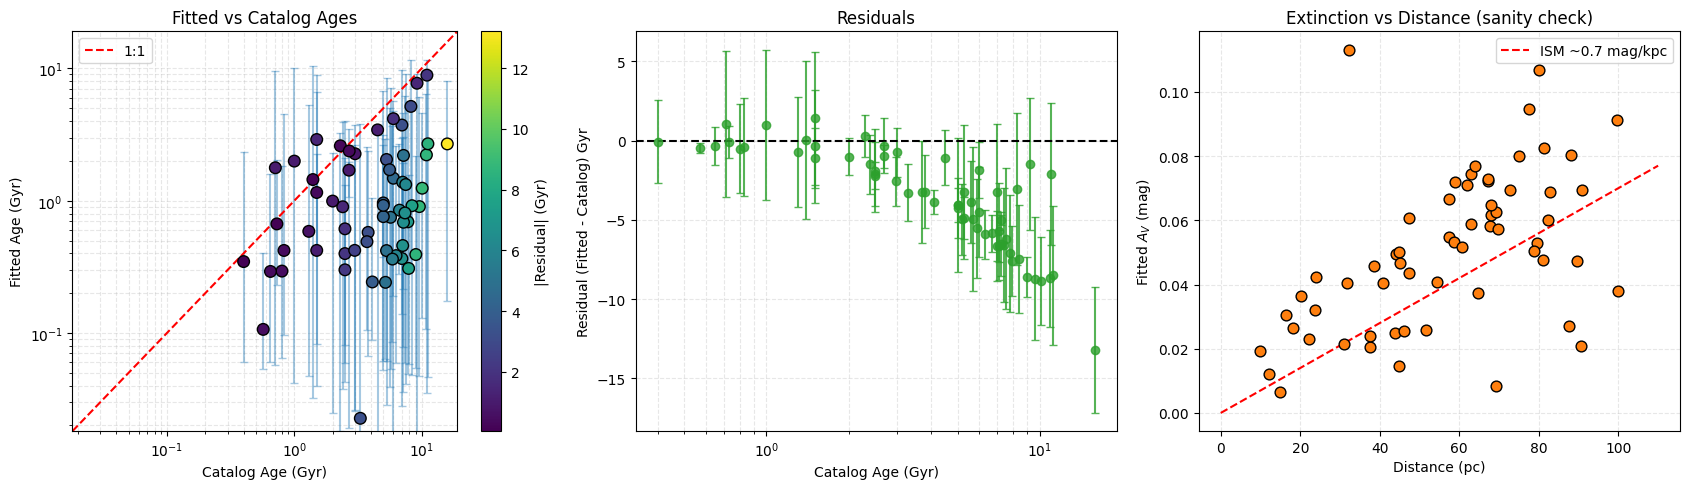

In [10]:
df = results_df.copy()
df["residual"]     = df["age_median"] - df["age_catalog"]
df["abs_residual"] = df["residual"].abs()

min_val = min(df["age_catalog"].min(), df["age_median"].min()) * 0.8
max_val = max(df["age_catalog"].max(), df["age_median"].max()) * 1.2
lims = [min_val, max_val]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# panel 1: fitted vs catalog
ax = axes[0]
sc = ax.scatter(
    df["age_catalog"], df["age_median"],
    c=df["abs_residual"], cmap="viridis", s=70, edgecolor="k", zorder=3
)
ax.errorbar(
    df["age_catalog"], df["age_median"],
    yerr=[df["age_median"] - df["age_lo"], df["age_hi"] - df["age_median"]],
    fmt="none", alpha=0.4, capsize=3
)
ax.plot(lims, lims, "r--", lw=1.5, label="1:1")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims);    ax.set_ylim(lims)
fig.colorbar(sc, ax=ax, label="|Residual| (Gyr)")
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Fitted Age (Gyr)")
ax.set_title("Fitted vs Catalog Ages")
ax.legend(); ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 2: residuals
ax = axes[1]
ax.errorbar(
    df["age_catalog"], df["residual"],
    yerr=df["age_err"], fmt="o", capsize=3, alpha=0.8, color="tab:green"
)
ax.axhline(0, color="k", ls="--", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Residual (Fitted - Catalog) Gyr")
ax.set_title("Residuals")
ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 3: fitted Av vs distance (sanity check)
ax = axes[2]
ax.scatter(
    merged_sample["distance_pc"].values, df["Av_median"],
    c="tab:orange", edgecolor="k", s=60, zorder=3
)
d_range = np.linspace(0, 110, 100)
ax.plot(d_range, 0.0007 * d_range, "r--", label="ISM ~0.7 mag/kpc")
ax.set_xlabel("Distance (pc)")
ax.set_ylabel(r"Fitted $A_V$ (mag)")
ax.set_title("Extinction vs Distance (sanity check)")
ax.legend(); ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/march30_results.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 10. Color-coded Results Table

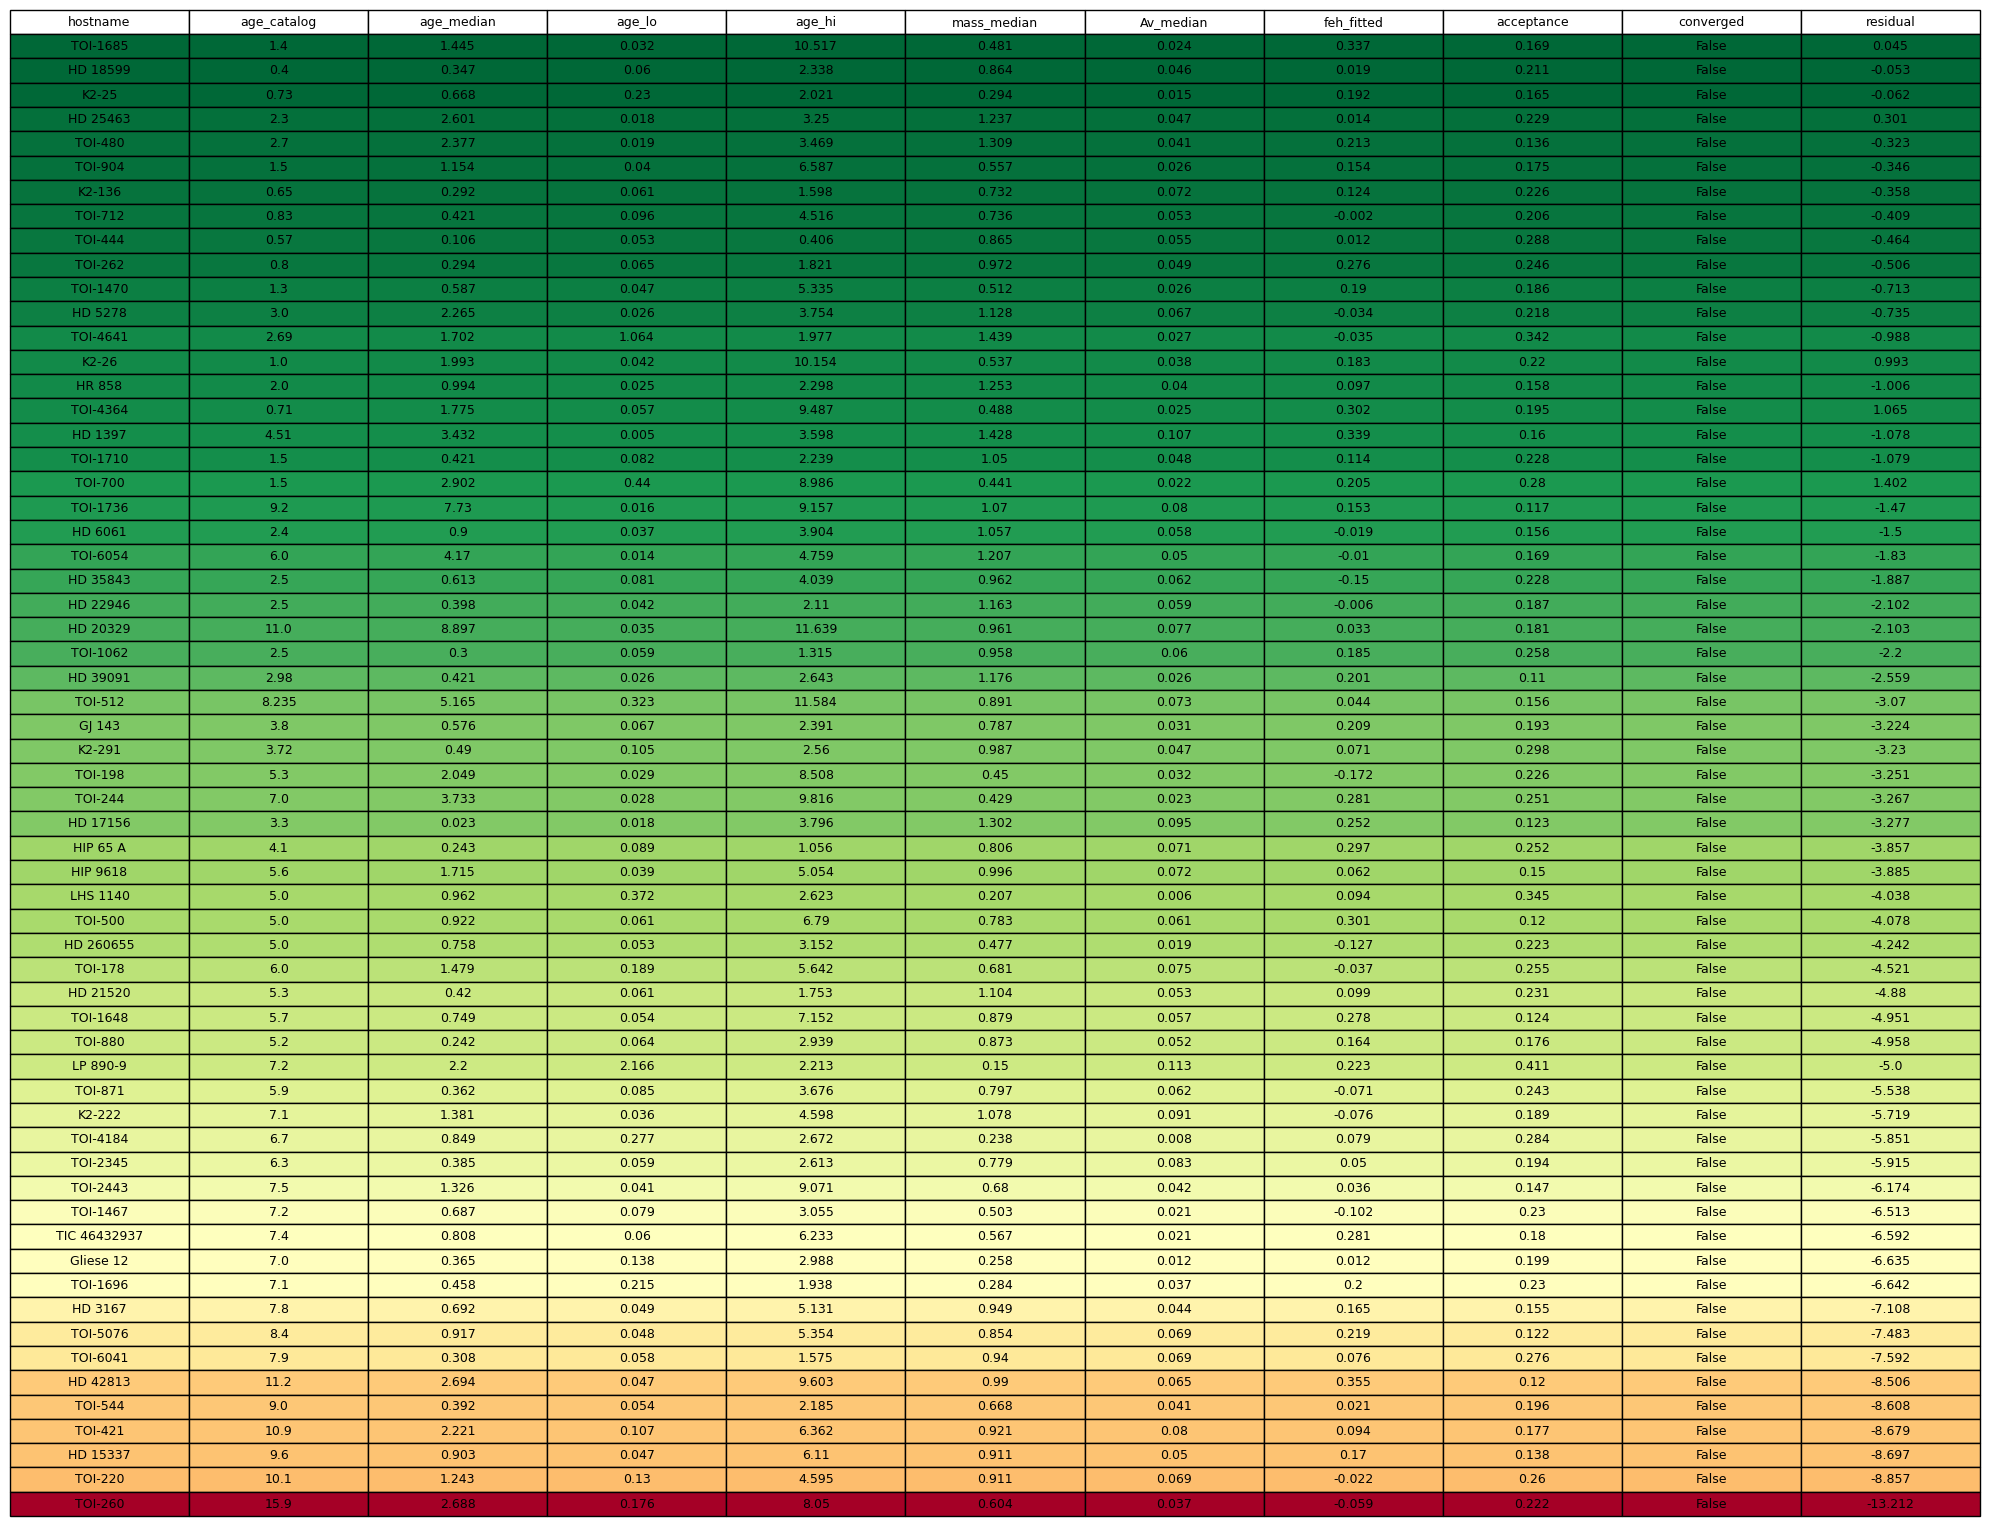

In [11]:
show_cols = [
    "hostname", "age_catalog", "age_median", "age_lo", "age_hi",
    "mass_median", "Av_median", "feh_fitted", "acceptance", "converged", "residual"
]
df_show = df.round(3).sort_values("abs_residual").reset_index(drop=True)[show_cols]

norm = plt.Normalize(df["abs_residual"].min(), df["abs_residual"].max())
cmap = plt.cm.RdYlGn_r

cell_colors = []
for _, row in df_show.iterrows():
    c = cmap(norm(abs(row["residual"])))
    cell_colors.append([c] * len(show_cols))

fig, ax = plt.subplots(figsize=(20, max(6, len(df_show) * 0.25)))
ax.axis("off")
tbl = ax.table(
    cellText=df_show.values,
    colLabels=df_show.columns,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
plt.tight_layout()
plt.show()

## 11. Corner Plot for a Single Star

Change `TARGET` to any hostname in your results.

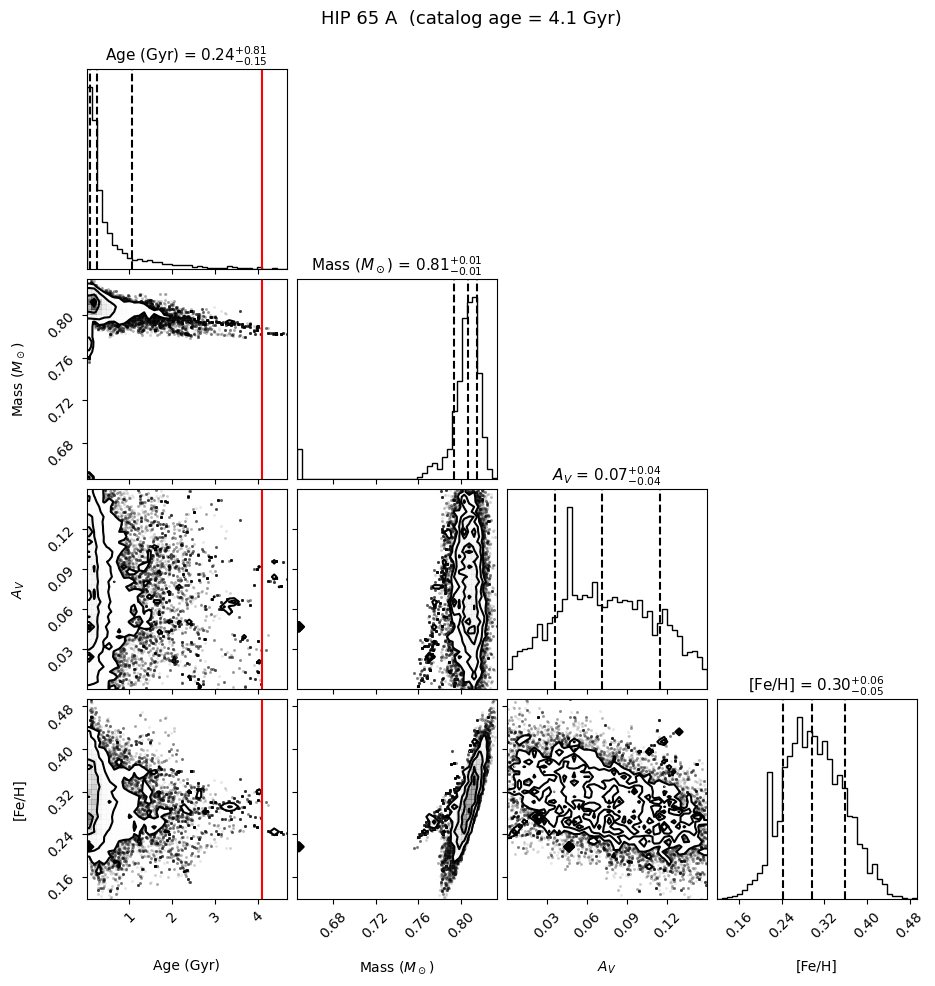

In [12]:
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("corner not installed — run: pip install corner")

if HAS_CORNER and len(results_df) > 0:
    TARGET = results_df.iloc[0]["hostname"]   # change this
    idx    = results_df[results_df["hostname"] == TARGET].index[0]
    samps  = sample_list[idx].copy()
    samps[:, 0] = 10 ** samps[:, 0] / 1e9   # convert logage -> Gyr

    cat_age = results_df.loc[idx, "age_catalog"]

    fig = corner.corner(
        samps,
        labels=["Age (Gyr)", r"Mass ($M_\odot$)", r"$A_V$", "[Fe/H]"],
        truths=[cat_age, None, None, None],
        truth_color="red",
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 11},
        bins=40,
    )
    fig.suptitle(f"{TARGET}  (catalog age = {cat_age:.1f} Gyr)",
                 fontsize=13, y=1.02)
    plt.show()